In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import CategoricalCrossentropy
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [ ]:
#X_train, X_test, y_train, y_test = joblib.load("ecg_split_data.pkl")

In [13]:
X_train = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

In [14]:
y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)

In [15]:
import numpy as np
np.bincount(np.argmax(y_train, axis=1))


array([75683,  2223,  5788,   641,  6431,  8429])

In [16]:
# Convert from one-hot to int labels
y_train_int = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.21844403630934292), 1: np.float64(7.4370220422852), 2: np.float64(2.8563407049067036), 3: np.float64(25.79173166926677), 4: np.float64(2.570751049603483), 5: np.float64(1.9613833194922292)}


In [17]:
model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(6, activation='softmax')
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

c:\Users\hawra\anaconda3\envs\tf-env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# Optional: Add early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 64s 20ms/step - accuracy: 0.2089 - loss: 1.5607 - val_accuracy: 0.3105 - val_loss: 1.5322
Epoch 2/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.2791 - loss: 1.2984 - val_accuracy: 0.2942 - val_loss: 1.3839
Epoch 3/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.3397 - loss: 1.0345 - val_accuracy: 0.4075 - val_loss: 1.2115
Epoch 4/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.4474 - loss: 0.8148 - val_accuracy: 0.6414 - val_loss: 0.8615
Epoch 5/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 64s 21ms/step - accuracy: 0.5814 - loss: 0.6589 - val_accuracy: 0.5562 - val_loss: 1.1038
Epoch 6/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 66s 21ms/step - accuracy: 0.6446 - loss: 0.5981 - val_accuracy: 0.6227 - val_loss: 0.9443
Epoch 7/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 65s 21ms/step - accuracy: 0.6683 - loss: 0.5720 - val_accuracy: 0.7044 - val_loss: 0.7597
Epoch 8/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 65s 21ms/step - accuracy: 0.7143 -

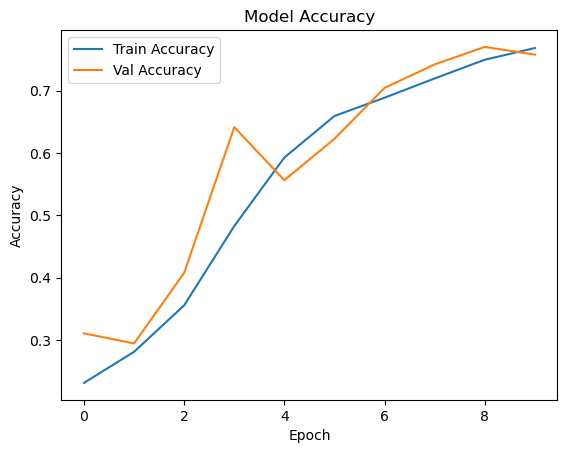

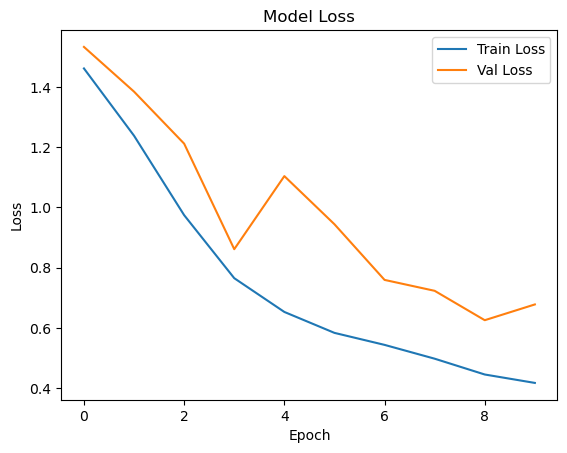

In [19]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


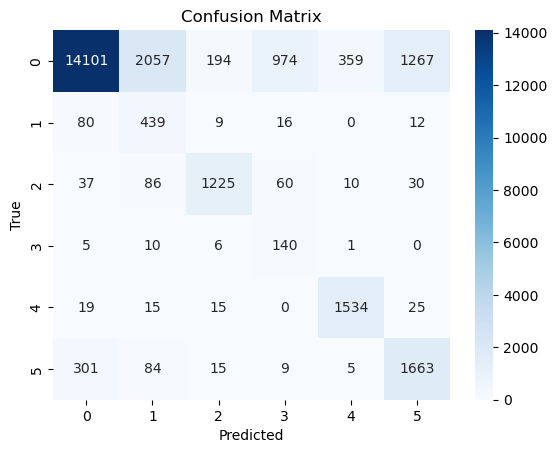

              precision    recall  f1-score   support

           0       0.97      0.74      0.84     18952
           1       0.16      0.79      0.27       556
           2       0.84      0.85      0.84      1448
           3       0.12      0.86      0.21       162
           4       0.80      0.95      0.87      1608
           5       0.55      0.80      0.66      2077

    accuracy                           0.77     24803
   macro avg       0.57      0.83      0.61     24803
weighted avg       0.89      0.77      0.81     24803



In [20]:
import numpy as np


# Predict classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_true_classes, y_pred_classes))
